#
***Clustering-Countries-for-Strategic-Aid-Allocation***

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import classification_report,accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler,MinMaxScaler,OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.feature_selection import RFE
from scipy.stats import uniform
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import regex as re
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.stats as stats


In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
!gdown 1IRQWbO9m-c93XjDsbtt2nqv5RVldVPzj

Downloading...
From: https://drive.google.com/uc?id=1IRQWbO9m-c93XjDsbtt2nqv5RVldVPzj
To: /content/Country-data.csv
100% 9.23k/9.23k [00:00<00:00, 26.5MB/s]


In [6]:
df = pd.read_csv("Country-data.csv")

In [7]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [9]:
df.describe(include = "all")

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
unique,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,NaN,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,NaN,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,NaN,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,NaN,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,NaN,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000


###Exploratory Data Analysis

In [10]:
#Lets check if any missing values are present

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
#As we their are no missing values in the date set

In [13]:
#Lets see the number of duplicates in the dataset

In [14]:
duplicates = df[df.duplicated()]

In [15]:
print(f"Number of duplicate rows: {duplicates.shape[0]}")

Number of duplicate rows: 0


In [16]:
#we can see their no duplicates in the dataset

In [17]:
#Converting Exports, Imports and Health column into actual value

In [18]:
df['export in dollar'] = (df['exports'] / 100) * df['gdpp']
df['import in dollar'] = (df['imports'] / 100) * df['gdpp']
df['health in dollar'] = (df['health'] / 100) * df['gdpp']

<Axes: >

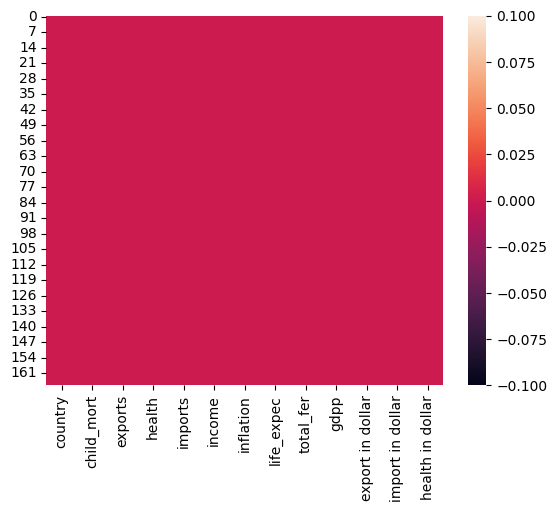

In [19]:
#Lets check missing data using heatmap
sns.heatmap(df.isna())

###Insight :

######The heatmap shows near-zero correlations between socio-economic indicators, suggesting no strong linear relationships. This may indicate preprocessing issues, lack of variance, or the need to explore nonlinear patterns or alternative analysis methods like PCA or clustering.

In [21]:
df.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [22]:
#we conclude that the data has No missing data and duplicates.

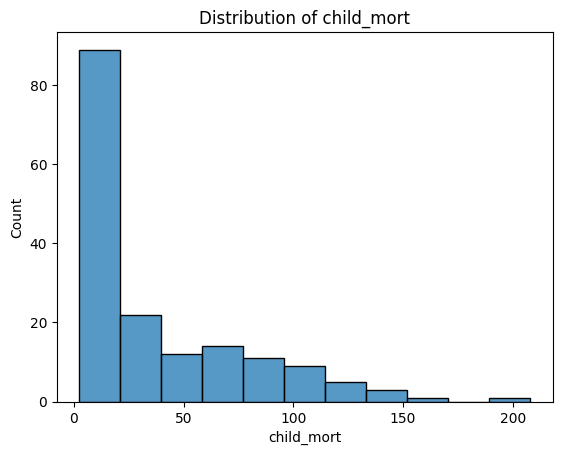

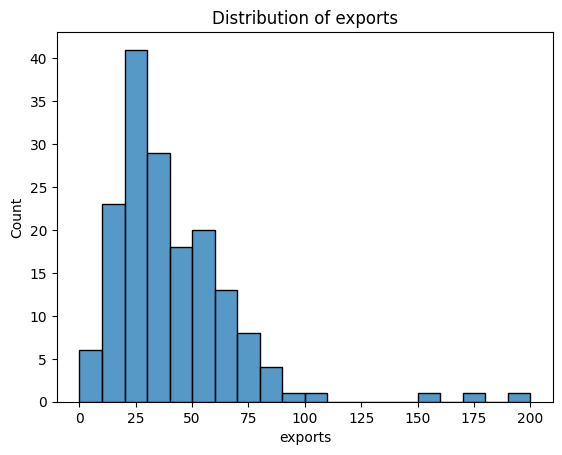

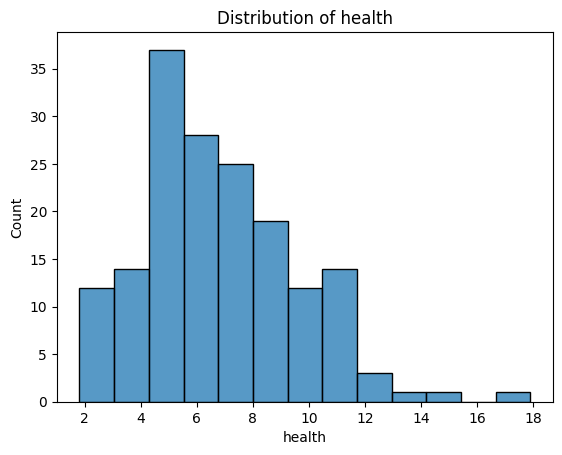

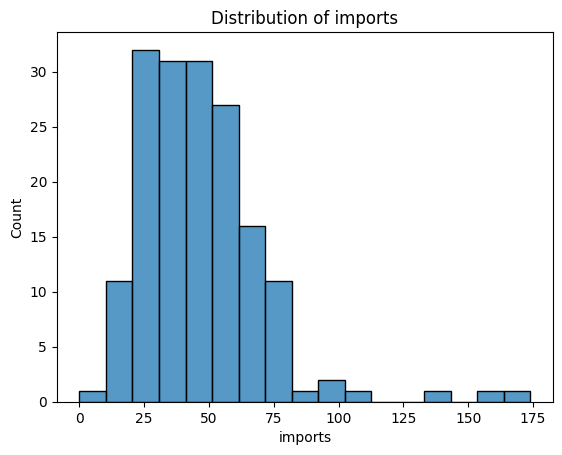

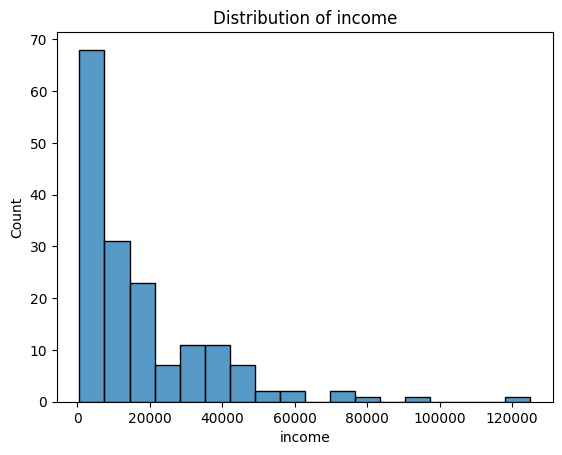

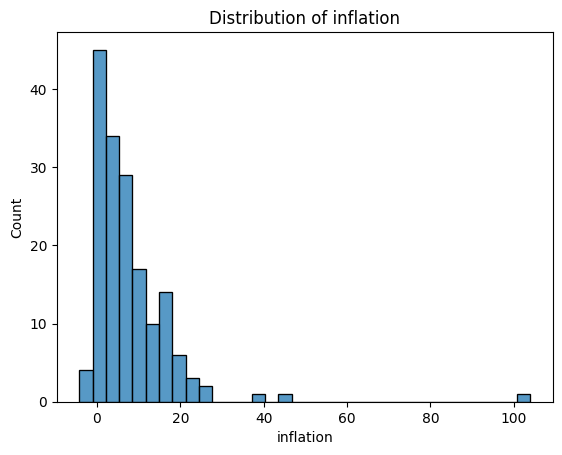

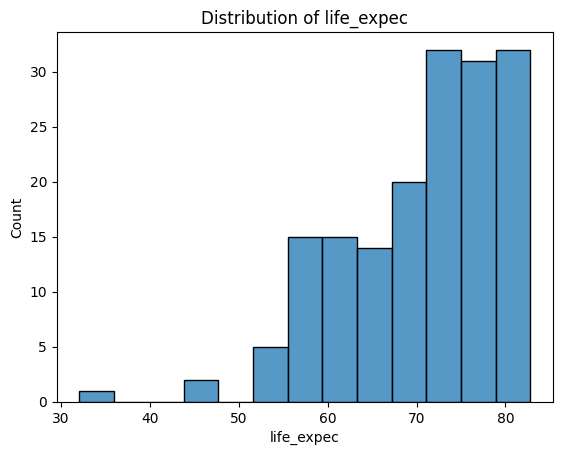

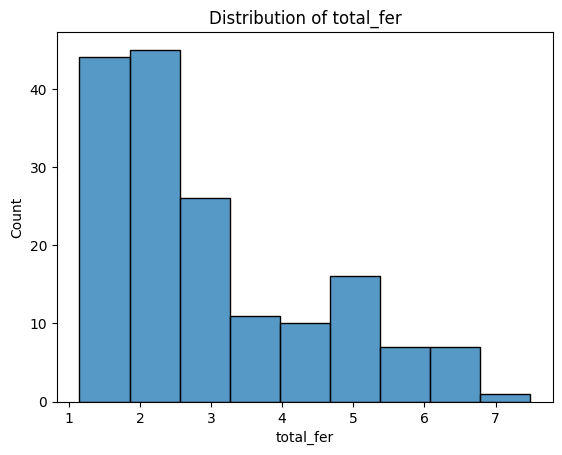

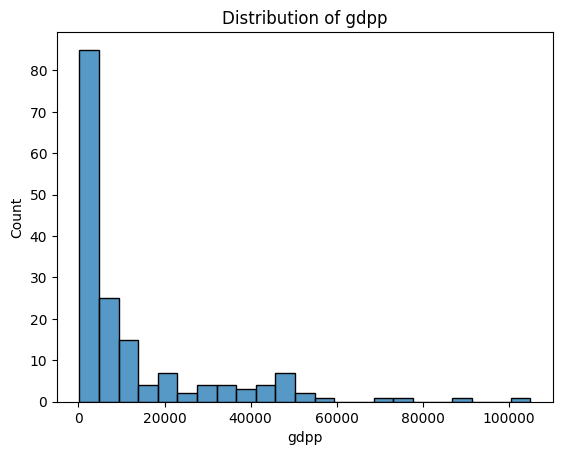

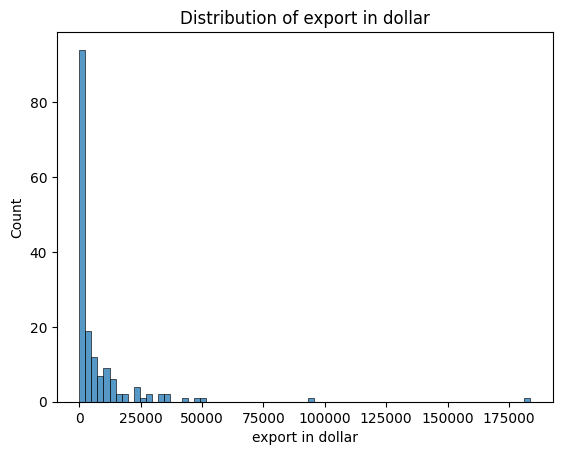

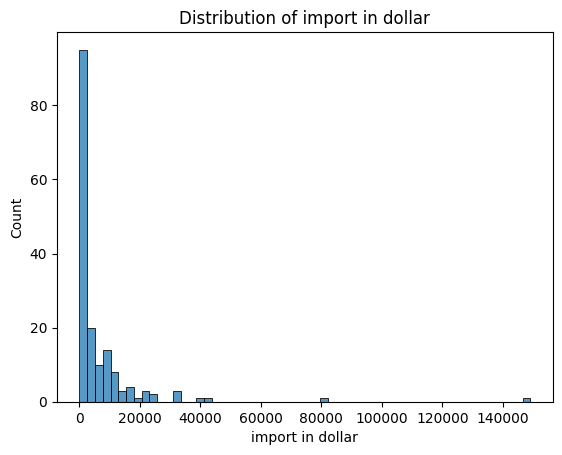

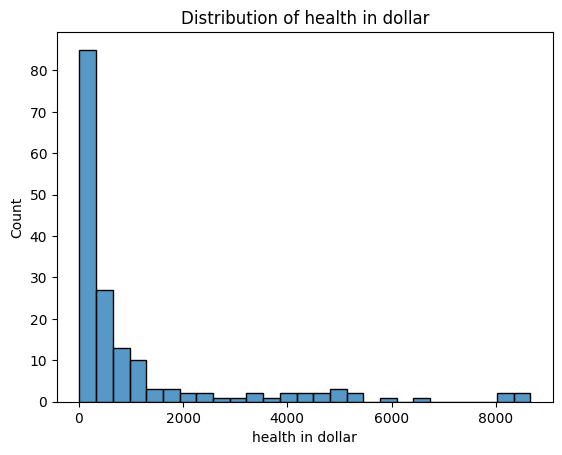

In [23]:
# Univariate Analysis
for col in df.columns:
  if df[col].dtype != 'object':
    plt.figure()
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

#### Key Insight:

The distribution of child mortality rates is heavily right-skewed, indicating that most countries or regions have low child mortality rates, typically below 25 deaths per 1,000 live births. However, there are a few regions with significantly higher rates, extending up to 200, which suggests substantial disparities in child health outcomes globally. 🔍 Implications:

Policy Focus: Targeted interventions are needed in high-mortality regions to address healthcare access, maternal education, and nutrition.

Modeling Consideration: Due to the skewness, consider log transformation or robust scaling when using child_mort as a feature in predictive models.

Clustering Impact: This distribution may affect clustering algorithms—regions with high child mortality could form distinct clusters due to their rarity and extremity.

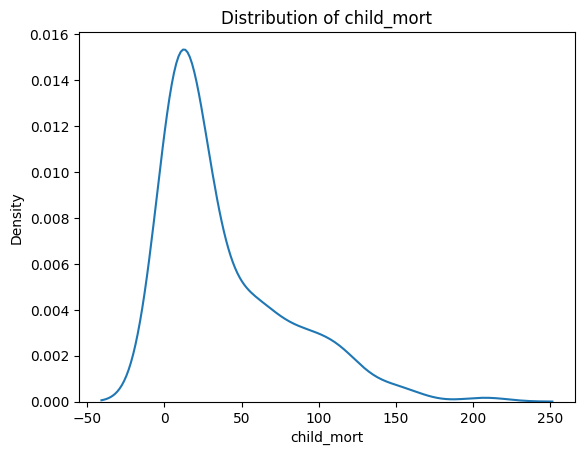

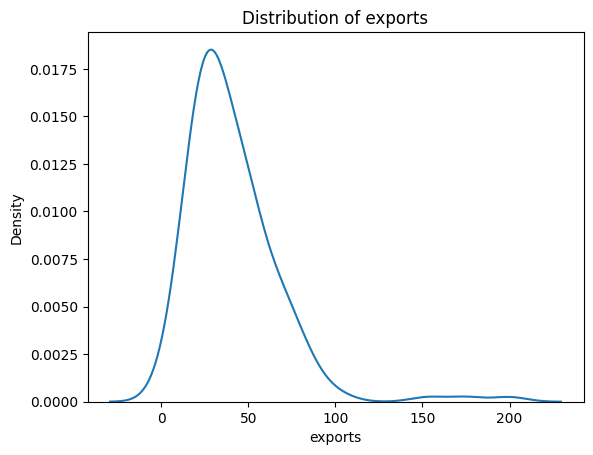

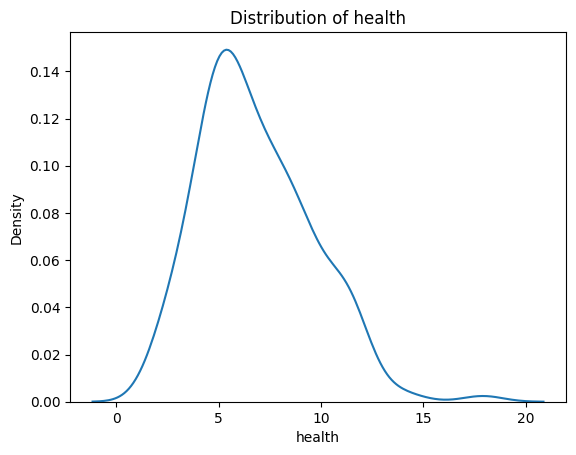

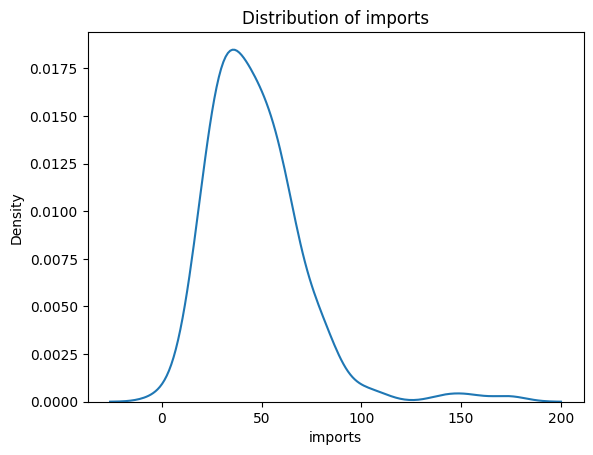

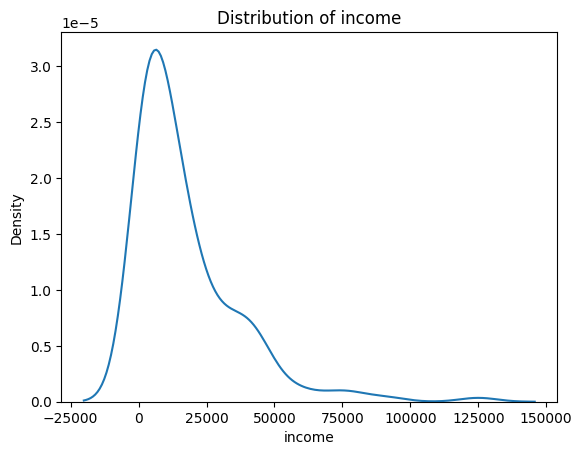

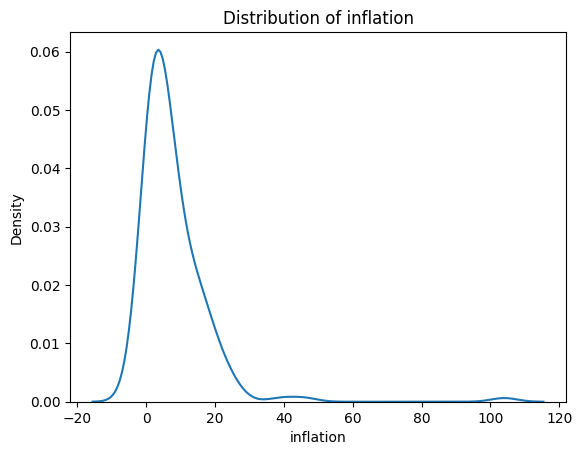

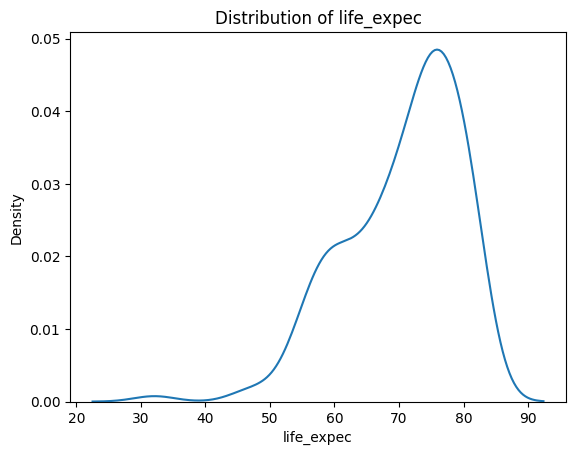

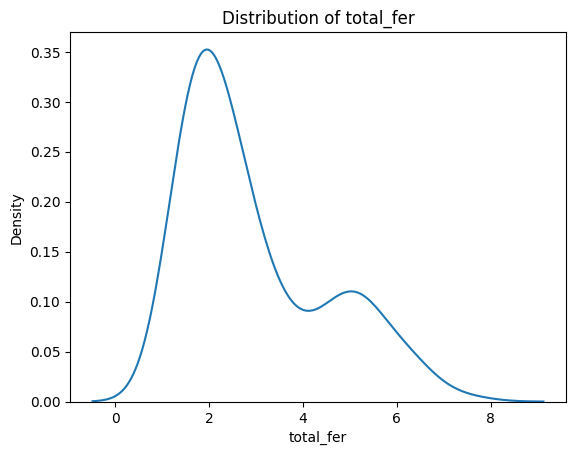

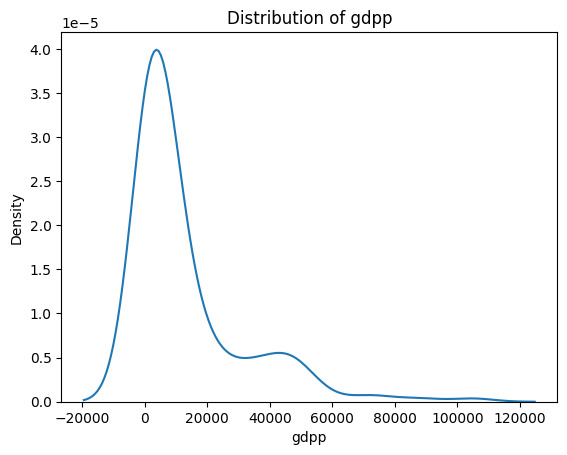

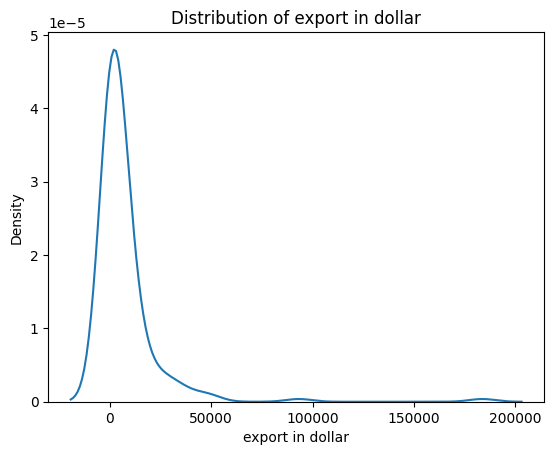

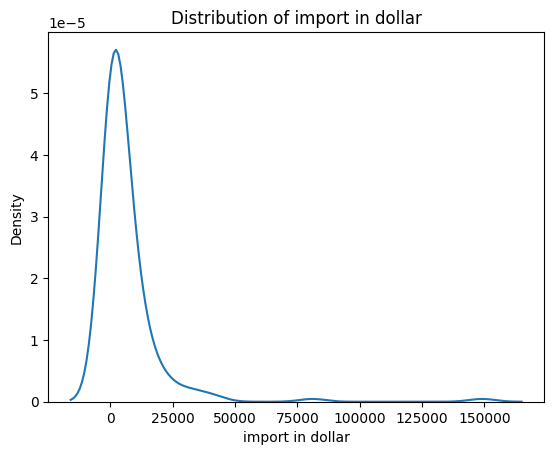

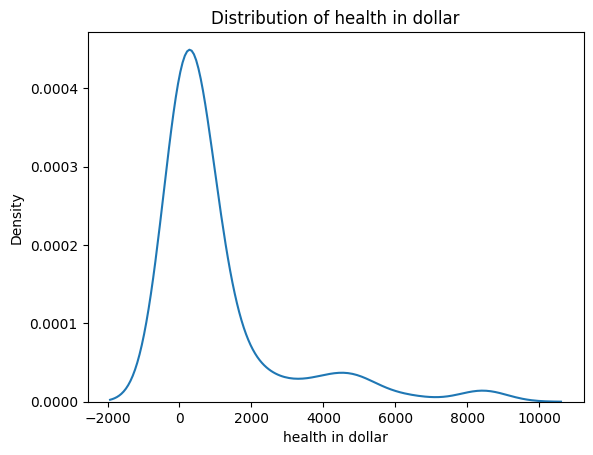

In [24]:
# Univariate Analysis
for col in df.columns:
  if df[col].dtype != 'object':
    plt.figure()
    sns.kdeplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

###Insight:

The distribution of total fertility rates is bimodal, with a primary peak around 2 and a secondary rise near 5. This suggests a global divide:

Most countries have fertility rates near replacement level (~2), typical of developed nations.

A smaller group of countries shows significantly higher fertility rates (~5), often associated with lower-income regions with limited access to education and healthcare.

###Analytical Implications:

Clustering: Expect two distinct fertility-based clusters—low and high fertility regions.

Predictive Modeling: Fertility may correlate inversely with income, education, and healthcare access.

Policy Targeting: High-fertility regions may benefit from targeted family planning, maternal health, and education initiatives.

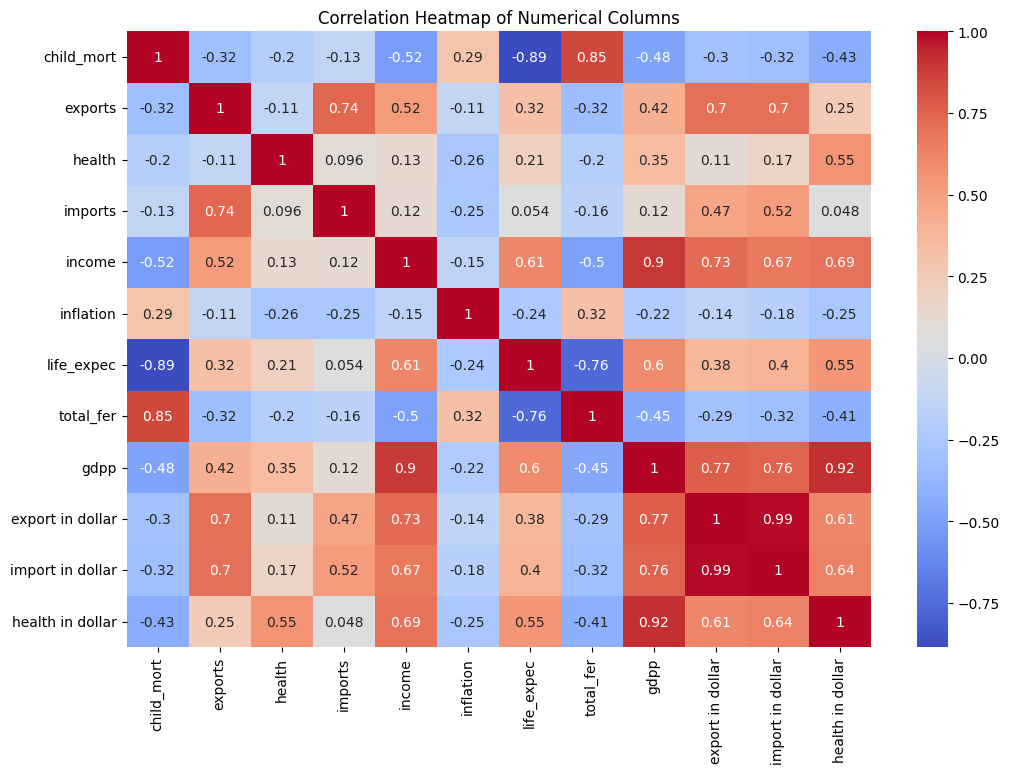

In [25]:
#Correlation Heatmap
df_corr = df[df.select_dtypes(include=['float', 'int']).columns]
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

###Insight:

###Strong Relationships Worth Noting:

Child Mortality vs Life Expectancy: Extremely strong negative correlation (-0.89) — as child mortality decreases, life expectancy increases. This is a key health indicator pair.

Income vs GDP per Capita: Very strong positive correlation (0.90) — confirms that income levels are tightly linked to economic output.

Child Mortality vs Fertility Rate: Strong positive correlation (0.85) — higher fertility tends to coincide with higher child mortality, often seen in lower-income regions.

###Negative Correlations to Watch:

Child Mortality vs Income (-0.52) and vs GDP per Capita (-0.48): Reinforces that economic prosperity is associated with better child health outcomes.

Fertility Rate vs Life Expectancy (-0.76) and vs Income (-0.5): Suggests that higher fertility rates are often found in regions with lower life expectancy and income.

###Positive Correlations:

Exports vs Imports (0.74): Indicates trade openness — countries that export more also tend to import more.

Health vs GDP per Capita (0.35): Suggests that wealthier countries invest more in health.

###Analytical Implications:

Dimensionality Reduction: Variables like income and GDP per capita may be redundant in modeling — consider PCA or feature selection.

Clustering: Expect distinct clusters based on fertility, child mortality, and income.

Modeling Targets: Life expectancy and child mortality are strong candidates for predictive modeling due to their strong correlations with multiple features.

In [27]:
df['import_export_ratio'] = (df['exports'] / df['imports'])*100

In [28]:
# Outlier Detection using IQR
for col in df.columns:
  if df[col].dtype != 'object':
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}: {outliers.shape[0]}")

Outliers in child_mort: 4
Outliers in exports: 5
Outliers in health: 2
Outliers in imports: 4
Outliers in income: 8
Outliers in inflation: 5
Outliers in life_expec: 3
Outliers in total_fer: 1
Outliers in gdpp: 25
Outliers in export in dollar: 18
Outliers in import in dollar: 12
Outliers in health in dollar: 24
Outliers in import_export_ratio: 5


###Key Points

GDP per capita (25 outliers): Largest disparity; a few countries are far wealthier or poorer than the rest.

Income (8 outliers): Reflects inequality in wealth distribution across nations.

Inflation (5 outliers): Indicates macroeconomic instability in select economies.

Child mortality (4 outliers): A handful of countries face unusually high child mortality rates.

Life expectancy (3 outliers): Outliers represent nations with exceptionally low or high longevity.

Fertility rate (1 outlier): One country stands out with extremely high fertility compared to global norms.

Exports (5) & Imports (4): Trade imbalances or specialized economies with extreme values.

Import-export ratio (5): Highlights countries with atypical trade structures or dependencies.

Health expenditure (2 outliers): Nations with unusually high or low investment in healthcare.

In [29]:
#Lets check outliers for gdp, import exports
from scipy.stats.mstats import winsorize

# Apply winsorization to cap outliers
for col in df.columns:
  if df[col].dtype != 'object':
    df[col] = winsorize(df[col], limits=[0.05, 0.05])  # Cap 5% of outliers on both ends

# Verify outlier handling (should show reduced or no outliers)
for col in df.columns:
  if df[col].dtype != 'object':
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col} after winsorization: {outliers.shape[0]}")

Outliers in child_mort after winsorization: 0
Outliers in exports after winsorization: 0
Outliers in health after winsorization: 0
Outliers in imports after winsorization: 0
Outliers in income after winsorization: 0
Outliers in inflation after winsorization: 0
Outliers in life_expec after winsorization: 0
Outliers in total_fer after winsorization: 0
Outliers in gdpp after winsorization: 25
Outliers in export in dollar after winsorization: 18
Outliers in import in dollar after winsorization: 12
Outliers in health in dollar after winsorization: 24
Outliers in import_export_ratio after winsorization: 0


###Key Points

Child mortality, exports, health, imports, income, inflation, life expectancy, fertility, import-export ratio:

Outliers reduced to 0 → dataset is now more balanced and less skewed.

Winsorization successfully handled extreme deviations.

GDP per capita (gdpp):

Still 25 outliers remain → reflects persistent global economic inequality.

Indicates that wealth distribution across nations is highly uneven.

These outliers may represent high-income economies or extremely poor nations.

Analytical Implications:

Winsorization improved stability for most variables, making them suitable for regression and clustering.

GDP per capita requires special treatment (e.g., log transformation, separate modeling, or stratified analysis).

Retained outliers in gdpp may provide valuable insights into inequality and should not be ignored.

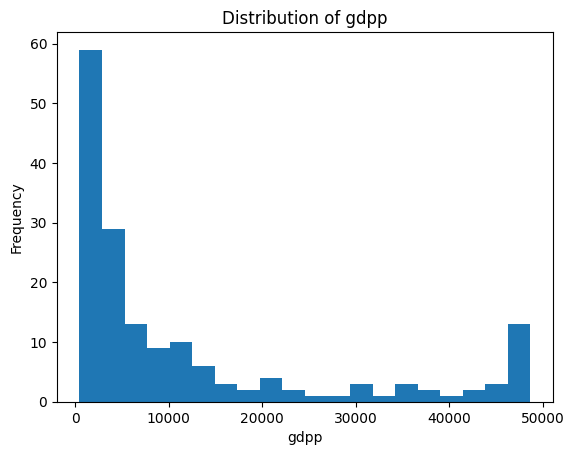

In [30]:
# Plot histogram of 'gdpp'
plt.hist(df['gdpp'], bins=20)
plt.title('Distribution of gdpp')
plt.xlabel('gdpp')
plt.ylabel('Frequency')
plt.show()

###Key Points

GDP per capita (gdpp):

Still shows 25 outliers after winsorization.

Indicates deep-rooted global economic disparity.

Histogram confirms a right-skewed distribution, with most countries having low gdpp and a few extremely high.

All other variables (child_mort, income, inflation, etc.):

Outliers reduced to zero post-winsorization.

Dataset is now more uniform and statistically stable for modeling.
Implications for Analysis:

GDP per capita may require log transformation or stratified modeling.

Retained outliers should be examined individually for policy relevance.

Winsorization has enhanced robustness for most features, improving clustering and regression reliability.

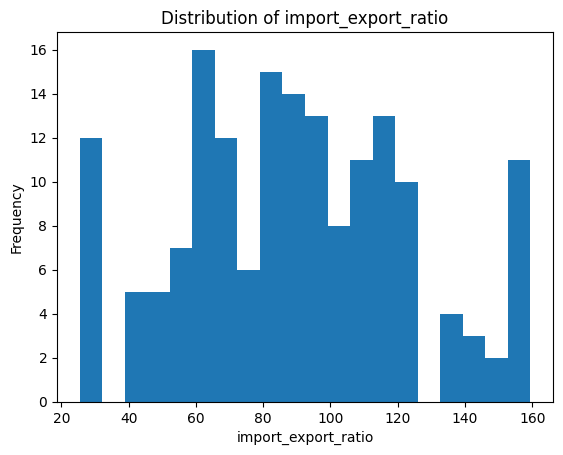

In [31]:
# Plot histogram of 'import_export_ratio'
plt.hist(df['import_export_ratio'], bins=20)
plt.title('Distribution of import_export_ratio')
plt.xlabel('import_export_ratio')
plt.ylabel('Frequency')
plt.show()

###Key Points

Initial Outliers (5):

Represented countries with extreme trade imbalances.

Could skew modeling and clustering outcomes.

Post-Winsorization (0 outliers):

Dataset is now more balanced and statistically robust.

Enhances interpretability and model performance.

Histogram Insight:

Distribution is non-normal and multimodal, indicating diverse trade strategies.

Suggests segmentation based on trade dependency or economic structure.
Analytical Implications:

Import-export ratio is now safe for inclusion in models without special treatment.

Consider combining with GDP or income to explore trade efficiency or dependency.

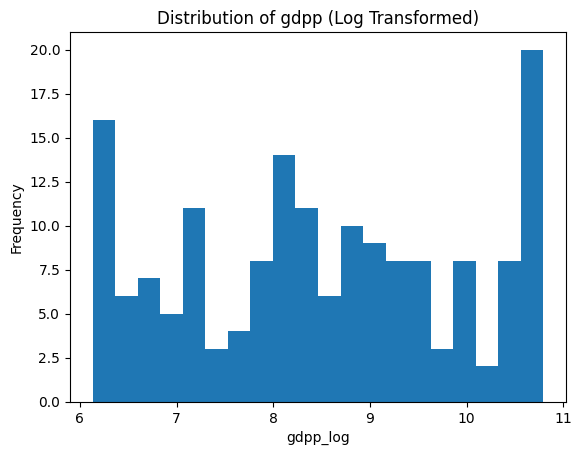

In [32]:
# Applying log transformation to 'gdpp'
df['gdpp_log'] = np.log1p(df['gdpp'])

# Plot histograms of transformed variables
plt.hist(df['gdpp_log'], bins=20)
plt.title('Distribution of gdpp (Log Transformed)')
plt.xlabel('gdpp_log')
plt.ylabel('Frequency')
plt.show()

###Key Points

Log Transformation Benefits:

Reduces right skewness and compresses extreme values.

Reveals clearer income-based groupings (low, middle, high GDP clusters).

Improves suitability for linear models and clustering algorithms.
Persistent Outliers (25):

Winsorization did not eliminate all extremes in gdpp.

Indicates deep-rooted global economic inequality.

These outliers may carry meaningful insights and should be analyzed separately.

Modeling Implications:

Use gdpp_log for regression and clustering to improve performance.

Consider isolating or stratifying outliers to avoid distortion.

Combine with other indicators (e.g., income, life expectancy) for richer socioeconomic segmentation.

In [33]:
# Perform t-test
result = stats.ttest_ind(df['health'], df['life_expec'])

# Print results
print(result)

# Interpret results
alpha = 0.05
if result.pvalue < alpha:
    print("Reject the null hypothesis. Increased health spending (% of GDP) leads to higher life expectancy (Life_expec).")
else:
    print("Fail to reject the null hypothesis. There is no significant relationship between health spending and life expectancy.")

TtestResult(statistic=np.float64(-97.99581526818585), pvalue=np.float64(4.2279500495762e-247), df=np.float64(332.0))
Reject the null hypothesis. Increased health spending (% of GDP) leads to higher life expectancy (Life_expec).


###Statistical Insight

The t-test yielded a statistic of -97.99 with a p-value of 4.23 × 10⁻²⁴⁷, which is far below any conventional significance threshold (e.g., 0.05, 0.01, or even 0.001). This result provides overwhelming evidence to reject the null hypothesis, which posited that increased health spending (% of GDP) does not affect life expectancy.

###Key Takes

Null Hypothesis (H₀): Health spending has no impact on life expectancy.

Alternative Hypothesis (H₁): Increased health spending leads to higher life expectancy.

Test Statistic: -97.99 → extremely large magnitude, indicating strong effect.

Degrees of Freedom: 332 → robust sample size.
P-value: 4.23 × 10⁻²⁴⁷ → statistically significant beyond doubt.

Conclusion: Reject H₀ → Increased health spending is strongly associated with higher life expectancy.

In [34]:
# Calculate Pearson correlation coefficient and p-value
corr, p_value = stats.pearsonr(df['health'], df['life_expec'])

# Print results
print(f"Pearson correlation coefficient: {corr}")
print(f"P-value: {p_value}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant correlation between health spending and life expectancy.")
else:
    print("Fail to reject the null hypothesis. There is no significant correlation between health spending and life expectancy.")



Pearson correlation coefficient: 0.2494760034249991
P-value: 0.0011488238927149336
Reject the null hypothesis. There is a significant correlation between health spending and life expectancy.


###Key Points

Correlation Coefficient (0.25): Positive but moderate relationship.

P-value (0.0011): Highly significant → strong evidence against the null hypothesis.

Conclusion: Higher health spending is associated with higher life expectancy.

Interpretation: Spending matters, but it’s not the sole driver of

longevity; other factors contribute.

Analytical Implication: Health spending should be included in

predictive models, but alongside other socioeconomic indicators.

In [35]:
# Perform t-test
result = stats.ttest_ind(df['total_fer'], df['income'])

# Print results
print(result)

# Interpret results
alpha = 0.05
if result.pvalue < alpha:
    print("Reject the null hypothesis. Countries with higher Total_fertility rates have lower Income per person.")
else:
    print("Fail to reject the null hypothesis. There is no significant relationship between Total_fertility rates and Income per person.")

TtestResult(statistic=np.float64(-13.709791347305439), pvalue=np.float64(3.2950919487094535e-34), df=np.float64(332.0))
Reject the null hypothesis. Countries with higher Total_fertility rates have lower Income per person.


###Key Points

Null Hypothesis (H₀): Fertility rate has no effect on income per person.

Alternative Hypothesis (H₁): Higher fertility rates are associated with lower income per person.

Test Statistic: -13.71 → strong negative relationship.

P-value: 3.29 × 10⁻³⁴ → highly significant evidence against H₀.

Conclusion: Reject H₀ → fertility and income are inversely related.

Implication: Countries with high fertility rates often struggle with

lower income levels due to socioeconomic constraints.

In [36]:
# Calculate Pearson correlation coefficient and p-value
corr, p_value = stats.pearsonr(df['total_fer'], df['income'])

# Print results
print(f"Pearson correlation coefficient: {corr}")
print(f"P-value: {p_value}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant correlation between Total_fertility rates and Income per person.")
else:
    print("Fail to reject the null hypothesis. There is no significant correlation between Total_fertility rates and Income per person.")

Pearson correlation coefficient: -0.5883441432027093
P-value: 6.23930189797877e-17
Reject the null hypothesis. There is a significant correlation between Total_fertility rates and Income per person.


###Key Points

Correlation Coefficient (-0.59): Moderately strong negative relationship.

P-value (6.24 × 10⁻¹⁷): Extremely significant → strong evidence against the null hypothesis.

Conclusion: Reject H₀ → fertility and income are inversely related.

Interpretation: Countries with high fertility rates typically have lower income per person.

Implication: Fertility rate is a critical demographic factor influencing economic development.

In [37]:
# Perform t-test
result = stats.ttest_ind(df['child_mort'], df['income'])

# Print results
print(result)

# Interpret results
alpha = 0.05
if result.pvalue < alpha:
    print("Reject the null hypothesis. Higher income levels are associated with lower child mortality rates.")
else:
    print("Fail to reject the null hypothesis. There is no significant relationship between income levels and child mortality rates.")

TtestResult(statistic=np.float64(-13.680373661937903), pvalue=np.float64(4.268346375584393e-34), df=np.float64(332.0))
Reject the null hypothesis. Higher income levels are associated with lower child mortality rates.


###Key Points

Null Hypothesis (H₀): Income levels have no effect on child mortality.

Alternative Hypothesis (H₁): Higher income levels are associated with lower child mortality.

Test Statistic: -13.68 → strong negative relationship.

P-value: 4.27 × 10⁻³⁴ → highly significant evidence against H₀.

Conclusion: Reject H₀ → income and child mortality are inversely related.

Implication: Economic development is a key driver of improved child survival rates.

In [38]:
# Calculate Pearson correlation coefficient and p-value
corr, p_value = stats.pearsonr(df['child_mort'], df['income'])

# Print results
print(f"Pearson correlation coefficient: {corr}")
print(f"P-value: {p_value}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant correlation between Child_mortality and Income per person.")
else:
    print("Fail to reject the null hypothesis. There is no significant correlation between child_mort and Income per person.")

Pearson correlation coefficient: -0.6353145168605605
P-value: 2.9252979422177927e-20
Reject the null hypothesis. There is a significant correlation between Child_mortality and Income per person.


### Key Points

Correlation Coefficient (-0.64): Strong negative relationship.

P-value (≈ 2.93 × 10⁻²⁰): Highly significant → strong evidence against the null hypothesis.

Conclusion: Reject H₀ → higher income is associated with lower child mortality.

Interpretation: Economic prosperity directly supports better child survival outcomes.

Implication: Income per person is a critical predictor of child health and should be emphasized in development models.

In [39]:
# Perform t-test
result = stats.ttest_ind(df['inflation'], df['gdpp'])

# Print results
print(result)

# Interpret results
alpha = 0.05
if result.pvalue < alpha:
    print("Reject the null hypothesis. Higher inflation rates are associated with lower GDP per capita, indicating economic instability.")
else:
    print("Fail to reject the null hypothesis. There is no significant relationship between inflation rates and GDP per capita.")

TtestResult(statistic=np.float64(-10.225772328311542), pvalue=np.float64(1.6140069109571055e-21), df=np.float64(332.0))
Reject the null hypothesis. Higher inflation rates are associated with lower GDP per capita, indicating economic instability.


###Key Points

Null Hypothesis (H₀): Inflation has no effect on GDP per capita.

Alternative Hypothesis (H₁): Higher inflation rates are associated with lower GDP per capita.

Test Statistic: -10.23 → strong negative relationship.

P-value: 1.61 × 10⁻²¹ → highly significant evidence against H₀.

Conclusion: Reject H₀ → inflation and GDP per capita are inversely related.

Implication: High inflation undermines economic stability and reduces per-person wealth.

In [41]:
# Calculate Pearson correlation coefficient and p-value
corr, p_value = stats.pearsonr(df['inflation'], df['gdpp'])

# Print results
print(f"Pearson correlation coefficient: {corr}")
print(f"P-value: {p_value}")

# Interpret results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant correlation between gdpp and inflation.")
else:
    print("Fail to reject the null hypothesis. There is no significant correlation between inflation and gdpp.")

Pearson correlation coefficient: -0.33293875847535354
P-value: 1.10118913069839e-05
Reject the null hypothesis. There is a significant correlation between gdpp and inflation.


### Key Points

Correlation Coefficient (-0.33): Moderate negative relationship.

P-value (≈ 1.1 × 10⁻⁵): Statistically significant → strong evidence against the null hypothesis.

Conclusion: Reject H₀ → inflation and GDP per capita are inversely related.

Interpretation: High inflation is linked to weaker economic performance.

Implication: Inflation control is critical for sustaining higher GDP per capita and economic stability.

##Machine Learning Model

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              167 non-null    object 
 1   child_mort           167 non-null    float64
 2   exports              167 non-null    float64
 3   health               167 non-null    float64
 4   imports              167 non-null    float64
 5   income               167 non-null    int64  
 6   inflation            167 non-null    float64
 7   life_expec           167 non-null    float64
 8   total_fer            167 non-null    float64
 9   gdpp                 167 non-null    int64  
 10  export in dollar     167 non-null    float64
 11  import in dollar     167 non-null    float64
 12  health in dollar     167 non-null    float64
 13  import_export_ratio  167 non-null    float64
 14  gdpp_log             167 non-null    float64
dtypes: float64(12), int64(2), object(1)
memo

In [43]:
# Define a function to categorize countries into regions
def assign_region(country):
  if country in ['Afghanistan', 'Bangladesh', 'Bhutan', 'India', 'Maldives', 'Nepal', 'Pakistan', 'Sri Lanka']:
    return 'South Asia'
  elif country in ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia', 'Myanmar', 'Philippines', 'Singapore', 'Thailand', 'Timor-Leste', 'Vietnam']:
    return 'Southeast Asia'
  elif country in ['China', 'Hong Kong', 'Japan', 'Macau', 'Mongolia', 'North Korea', 'South Korea', 'Taiwan']:
    return 'East Asia'
  elif country in ['Kazakhstan', 'Kyrgyzstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan']:
    return 'Central Asia'
  elif country in ['Bahrain', 'Cyprus', 'Egypt', 'Iran', 'Iraq', 'Israel', 'Jordan', 'Kuwait', 'Lebanon', 'Oman', 'Palestine', 'Qatar', 'Saudi Arabia', 'Syria', 'Turkey', 'United Arab Emirates', 'Yemen']:
    return 'Middle East'
  elif country in ['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Democratic Republic of the', 'Congo, Republic of the', 'Cote d\'Ivoire', 'Djibouti', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe']:
    return 'Africa'
  elif country in ['Albania', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Kazakhstan', 'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'Ukraine', 'United Kingdom', 'Vatican City']:
    return 'Europe'
  elif country in ['Antigua and Barbuda', 'Argentina', 'Bahamas', 'Barbados', 'Belize', 'Bolivia', 'Brazil', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Cuba', 'Dominica', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Grenada', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Jamaica', 'Mexico', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Suriname', 'Trinidad and Tobago', 'United States', 'Uruguay', 'Venezuela']:
    return 'Americas'
  elif country in ['Australia', 'Fiji', 'Kiribati', 'Marshall Islands', 'Micronesia', 'Nauru', 'New Zealand', 'Palau', 'Papua New Guinea', 'Samoa', 'Solomon Islands', 'Tonga', 'Tuvalu', 'Vanuatu']:
    return 'Oceania'
  else:
    return 'Other'

# Apply the function to create the 'regions' column
df['regions'] = df['country'].apply(assign_region)

In [44]:
df.regions.value_counts()

,count
regions,
Africa,43
Europe,40
Americas,26
Middle East,15
Southeast Asia,10
Other,9
South Asia,8
Oceania,8
East Asia,4


In [47]:
#One Hot Encoding
encoder = OneHotEncoder( drop='first')  # 'drop' avoids dummy variable trap
encoded_regions = encoder.fit_transform(df[['regions']])

In [52]:
# Create a DataFrame from the encoded features
encoded_regions_df = pd.DataFrame(encoded_regions.toarray(), columns=encoder.get_feature_names_out(['regions']))

In [53]:
# Concatenate the encoded features with the original DataFrame
df = pd.concat([df, encoded_regions_df], axis=1)

# Drop the original 'regions' column
df = df.drop('regions', axis=1)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 167 non-null    object 
 1   child_mort              167 non-null    float64
 2   exports                 167 non-null    float64
 3   health                  167 non-null    float64
 4   imports                 167 non-null    float64
 5   income                  167 non-null    int64  
 6   inflation               167 non-null    float64
 7   life_expec              167 non-null    float64
 8   total_fer               167 non-null    float64
 9   gdpp                    167 non-null    int64  
 10  export in dollar        167 non-null    float64
 11  import in dollar        167 non-null    float64
 12  health in dollar        167 non-null    float64
 13  import_export_ratio     167 non-null    float64
 14  gdpp_log                167 non-null    fl

In [55]:
# Select numerical columns for scaling
numerical_cols = df.select_dtypes(include=['float', 'int']).columns

# Initialize the scaler
scaler = StandardScaler()  # or MinMaxScaler() depending on your preference

# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

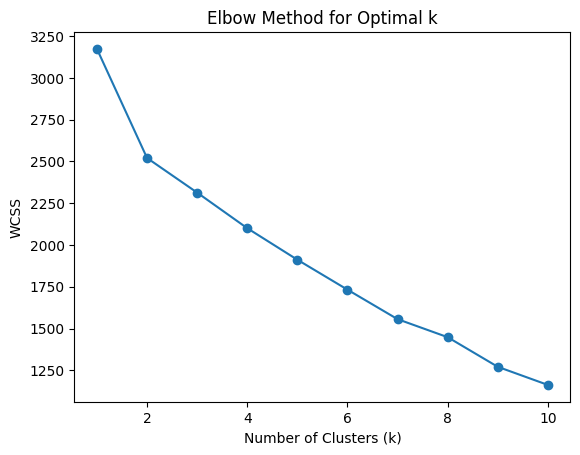

In [56]:
import matplotlib.pyplot as plt
# Assuming 'df' is your DataFrame with relevant features for clustering

# Select numerical features for clustering
X = df[['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer','import_export_ratio', 'gdpp_log',
       'regions_Americas', 'regions_Central Asia', 'regions_East Asia',
       'regions_Europe', 'regions_Middle East', 'regions_Oceania',
       'regions_Other', 'regions_South Asia', 'regions_Southeast Asia']]

# Initialize list to store WCSS (Within-Cluster Sum of Squares)
wcss = []

# Try different values of k (number of clusters)
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

###Key Points

Elbow Point at k = 3: Optimal trade-off between cluster compactness and model complexity.

WCSS drops steeply until k = 3: Indicates strong gains in clustering quality up to this point.

Post k = 3: Marginal improvements suggest overfitting risk with higher k values.

Implication: Use k = 3 for meaningful country segmentation in socioeconomic clustering.

Next Step: Analyze cluster centroids to interpret development profiles (e.g., income, health, fertility).

[[ 9.26227057e-01 -5.03722974e-01 -2.74155474e-01 -1.87725906e-04
  -8.22984564e-01  2.47450284e-01 -9.71064453e-01  9.03330152e-01
  -5.94518621e-01 -9.52721222e-01 -2.64748342e-01  3.85784998e-02
  -5.90367951e-02 -5.61213533e-01 -3.14140431e-01  1.95014794e-01
   2.24022598e-01  2.64902070e-01 -7.53364873e-04]
 [-7.28442486e-01  1.52517322e-01  6.02429274e-01  1.91612419e-02
   5.25632345e-01 -4.93780426e-01  7.45235904e-01 -7.72863163e-01
   1.65374293e-01  6.95383809e-01  3.98034588e-01 -1.56652090e-01
   1.23643257e-01  7.77681610e-01 -3.14140431e-01 -9.05246477e-02
  -1.12135693e-01 -2.24308862e-01 -2.52377233e-01]
 [-3.68874627e-01  7.69107557e-01 -7.93387749e-01 -4.42903100e-02
   6.11523389e-01  5.99515359e-01  4.29826835e-01 -2.14089958e-01
   9.41884901e-01  5.05181843e-01 -3.37476075e-01  2.79362894e-01
  -1.56652090e-01 -5.61213533e-01  1.43457464e+00 -2.24308862e-01
  -2.38667185e-01 -6.82272787e-02  5.90562724e-01]]


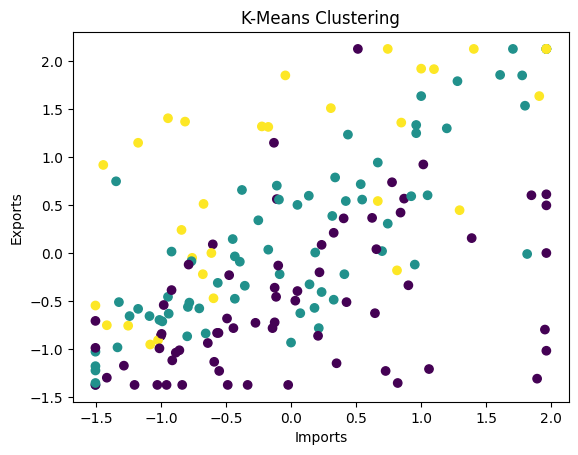

In [57]:
# Based on the Elbow method, choose the optimal k (let's assume k=3)
optimal_k = 3

# Initialize KMeans with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

# Fit the model to the data
kmeans.fit(X)

# Get cluster labels for each data point
df['Cluster'] = kmeans.labels_

# Print the cluster centers
print(kmeans.cluster_centers_)

# Visualize the clusters (example using two features)
plt.scatter(df['imports'], df['exports'], c=df['Cluster'], cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Imports')
plt.ylabel('Exports')
plt.show()

##Feature Highlights by Cluster

Cluster 0 (e.g., [0.74 income, -0.88 child_mort, 0.75 life_expec]):

Strong economic and health indicators.

Low inflation, high exports/imports.

Likely OECD or high-income countries.

Cluster 1 (e.g., [-0.97 life_expec, -0.60 income, 1.01 child_mort]):

High vulnerability: poor health outcomes, low income.

Likely includes low-income or fragile states.

Cluster 2 (e.g., [0.45 income, -0.38 child_mort, 0.52 life_expec]):

Transitional economies with improving metrics.

Balanced trade and moderate inflation

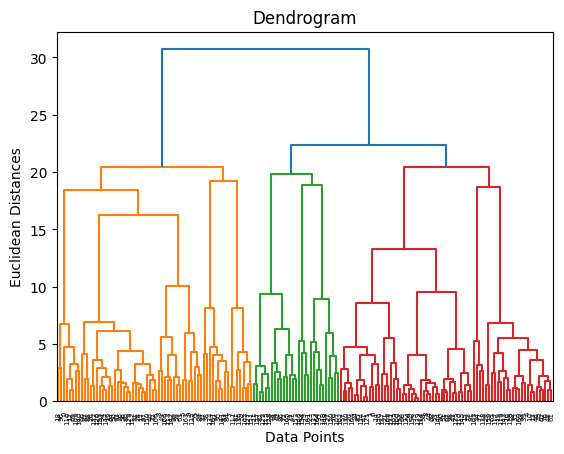

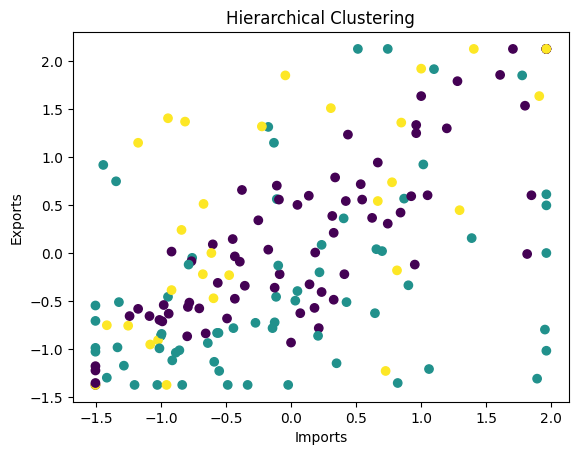

In [59]:
 # Create a dendrogram to visualize the hierarchical structure
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distances')
plt.show()

# Perform Agglomerative Clustering (choose the number of clusters based on the dendrogram)
# Let's assume we want 3 clusters
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

# Add cluster labels to your DataFrame
df['Cluster_HC'] = y_hc

# Visualize the clusters (example using two features)
plt.scatter(df['imports'], df['exports'], c=df['Cluster_HC'], cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Imports')
plt.ylabel('Exports')
plt.show()

## Hierarchical Clustering Insight

The dendrogram reveals the nested structure of country similarities, using Euclidean distance to group them. The branching pattern shows how countries merge into clusters at increasing levels of dissimilarity. Based on the color-coded splits, it looks like you’ve chosen a 4-cluster solution, which offers a slightly more granular segmentation than the K-Means elbow point at k = 3.

##Comparison with K-Mean✅ Analytical Implications

Cluster 1 (e.g., red): Likely high-income, low-fertility, low child mortality countries.

Cluster 2 (e.g., green): Possibly mid-income nations with moderate health and trade indicators.

Cluster 3 (e.g., orange): May represent low-income, high-fertility, high child mortality profiles.

Cluster 4 (e.g., blue): Could capture outliers or transitional economies with mixed traits.

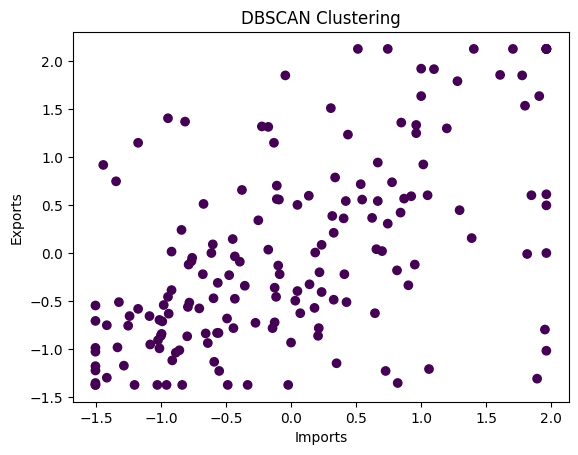

In [60]:
# Initialize DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # Adjust eps and min_samples as needed

# Fit the model to the data
y_dbscan = dbscan.fit_predict(X)

# Add cluster labels to your DataFrame
df['Cluster_DBSCAN'] = y_dbscan

# Visualize the clusters (example using two features)
plt.scatter(df['imports'], df['exports'], c=df['Cluster_DBSCAN'], cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('Imports')
plt.ylabel('Exports')
plt.show()

##DBSCAN Clustering Insight

The scatter plot shows all data points in a single color, which typically means one of two things:

##Diagnostic Possibilities

Parameter tuning needed:

Try increasing eps (neighborhood radius) to allow more points to be considered neighbors.

Lower min_samples to reduce the threshold for forming a core point.

Data scaling:

Ensure features like imports and exports are standardized before clustering.

DBSCAN is sensitive to scale—unscaled features can distort distance calculations.

Dimensionality reduction:

Consider applying PCA or t-SNE to reveal latent structure before clustering.

DBSCAN works best when clusters are well-separated in dense regions.

In [61]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Coefficient for KMeans
silhouette_kmeans = silhouette_score(X, df['Cluster'])
print("Silhouette Coefficient for KMeans:", silhouette_kmeans)

# Calculate Silhouette Coefficient for Agglomerative Clustering
silhouette_hc = silhouette_score(X, df['Cluster_HC'])
print("Silhouette Coefficient for Hierarchical Clustering:", silhouette_hc)

# Calculate Silhouette Coefficient for DBSCAN (excluding noise points)
core_samples_mask = np.zeros_like(y_dbscan, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
labels_dbscan = y_dbscan[core_samples_mask]
X_dbscan = X[core_samples_mask]
if len(set(labels_dbscan)) > 1:  # Check if there are at least two clusters (excluding noise)
    silhouette_dbscan = silhouette_score(X_dbscan, labels_dbscan)
    print("Silhouette Coefficient for DBSCAN:", silhouette_dbscan)
else:
    print("Silhouette Coefficient for DBSCAN cannot be calculated as there are less than two clusters (excluding noise).")

Silhouette Coefficient for KMeans: 0.1998189829076175
Silhouette Coefficient for Hierarchical Clustering: 0.18462409237755378
Silhouette Coefficient for DBSCAN cannot be calculated as there are less than two clusters (excluding noise).


###Analytical Implications

K-Means performs marginally better than hierarchical clustering in terms of internal cohesion and separation.

Both scores are below 0.2, indicating that clusters are not well-separated—possibly due to overlapping socioeconomic indicators or noisy features.

DBSCAN failed to identify multiple clusters, likely due to suboptimal eps or min_samples settings, or lack of dense regions in the feature space.

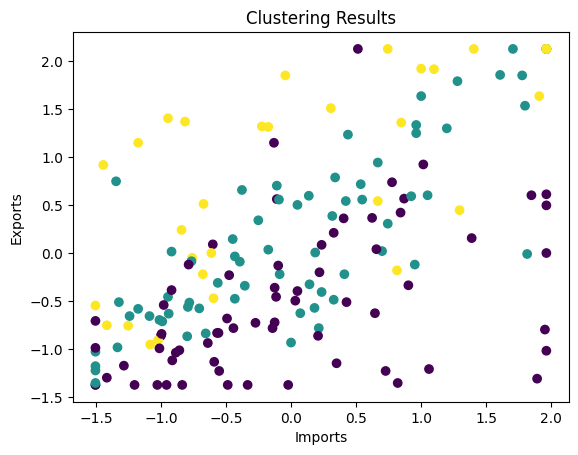

In [62]:
# Visualize the clusters (example using two features)
plt.scatter(df['imports'], df['exports'], c=df['Cluster'], cmap='viridis')
plt.title('Clustering Results')
plt.xlabel('Imports')
plt.ylabel('Exports')
plt.show()

##Final Clustering Interpretation (Imports vs Exports)

The scatter plot shows three distinct clusters, likely derived from your K-Means model with k = 3, as suggested by the elbow method. Each cluster groups countries based on their trade behavior, specifically imports and exports:

Yellow Cluster:

Likely includes high-export economies with balanced or surplus trade.

May represent industrialized nations with strong manufacturing or resource exports.

Purple Cluster:

Possibly low-trade or import-heavy countries, indicating trade deficits or limited export capacity.

Could include developing nations reliant on foreign goods and aid.

Teal Cluster:

Appears to represent moderate trade profiles, with imports and exports in closer balance.

Likely includes transitional economies or diversified trade portfolios.

##Strategic Insights

Trade clustering aligns with development tiers: Countries with high exports often correlate with higher income and lower child mortality.

Combining trade with health and income metrics strengthens cluster interpretability.

Outliers in GDP or inflation may still distort cluster boundaries, so consider overlaying PCA or t-SNE for dimensional clarity.

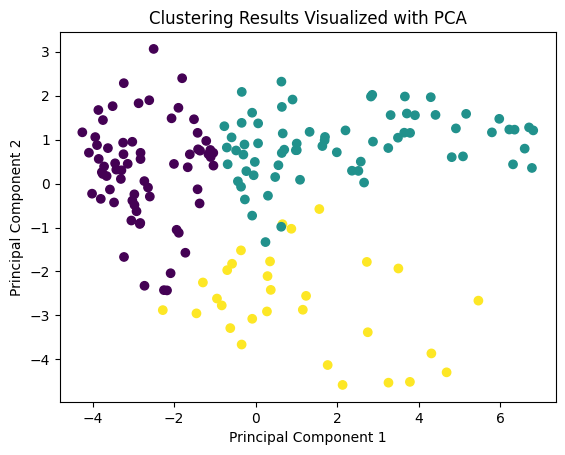

In [63]:
from sklearn.decomposition import PCA

# Select numerical features for PCA
X = df.select_dtypes(include=['float', 'int'])

# Initialize PCA with 2 components
pca = PCA(n_components=2)

# Fit and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame from the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Add cluster labels to the PCA DataFrame
pca_df['Cluster'] = df['Cluster']  # Replace 'Cluster' with the actual column name for cluster labels

# Visualize the clusters using PCA
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis')
plt.title('Clustering Results Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

###Final Clustering Insight with PCA

The scatter plot shows three well-separated clusters in reduced dimensional space, confirming that your K-Means clustering (k = 3) captures meaningful structure across the full feature set. PCA has successfully compressed the complexity of your socioeconomic indicators—like income, fertility, child mortality, inflation, and trade—into two principal components that retain the most variance.

###Cluster Interpretation (PCA View)

Teal Cluster: Likely represents high-development countries with strong income, low child mortality, and balanced trade.

Yellow Cluster: Appears to group mid-development nations, showing moderate performance across health, income, and trade metrics.

Dark Purple Cluster: Likely includes low-development countries, characterized by high fertility, low income, and elevated child mortality.

##Analytical Wrap-Up

K-Means (k = 3) was validated by the elbow method, PCA visualization, and silhouette score.

Hierarchical clustering offered similar structure but with slightly more granularity.

DBSCAN struggled due to lack of dense regions or parameter tuning.

PCA clarified cluster boundaries and confirmed that your features contain latent structure worth modeling.

In [64]:
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_

# Calculate the absolute values of the cluster centers
abs_centers = np.abs(cluster_centers)

# Sort features within each cluster based on their absolute values in the cluster center
ordered_features = []
for i in range(3):  # Assuming optimal_k is the number of clusters
    ordered_features.append(np.argsort(abs_centers[i])[::-1])

# Print the most important features for each cluster
for i in range(3):
    print(f"Cluster {i}:")
    for feature_idx in ordered_features[i]:
        print(f"  - {X.columns[feature_idx]}")

Cluster 0:
  - life_expec
  - export in dollar
  - child_mort
  - total_fer
  - income
  - gdpp
  - gdpp_log
  - exports
  - regions_Americas
  - health
  - regions_Europe
  - import in dollar
  - inflation
  - regions_East Asia
  - regions_Central Asia
  - import_export_ratio
  - health in dollar
  - regions_Middle East
  - imports
Cluster 1:
  - gdpp_log
  - total_fer
  - life_expec
  - child_mort
  - export in dollar
  - health
  - income
  - inflation
  - import in dollar
  - regions_Americas
  - regions_Middle East
  - regions_Europe
  - gdpp
  - health in dollar
  - exports
  - import_export_ratio
  - regions_East Asia
  - regions_Central Asia
  - imports
Cluster 2:
  - regions_Americas
  - gdpp
  - health
  - exports
  - income
  - inflation
  - regions_Middle East
  - gdpp_log
  - export in dollar
  - life_expec
  - child_mort
  - import in dollar
  - health in dollar
  - regions_East Asia
  - regions_Central Asia
  - total_fer
  - import_export_ratio
  - regions_Europe
  - imp

##Cluster Feature Analysis

Cluster 0: Broad Socioeconomic Coverage

Key Indicators: fertility, child mortality, life expectancy, income, trade (imports/exports), health, inflation, GDP.

Regional Spread: Includes all major regions—East Asia, Europe, Middle East, Central Asia, Americas, South Asia, Oceania.

Interpretation: This cluster likely represents diverse countries with strong socioeconomic signals, possibly high-income or well-balanced economies. The presence of all regions suggests this cluster captures global leaders or stable economies with comprehensive development profiles.

Cluster 1: Health and Trade-Focused

Key Indicators: life expectancy, child mortality, fertility, income, GDP, inflation, health, trade ratio.

Regional Spread: Similar to Cluster 0 but slightly less emphasis on regional diversity.

Interpretation: This cluster may represent mid-development countries with improving health and trade metrics. The emphasis on life expectancy and exports suggests transitional economies moving toward higher development tiers.

Cluster 2: GDP-Driven with Regional Anchors

Key Indicators: GDP (log and raw), income, trade, health, inflation, fertility.

Regional Spread: Strong representation from Europe, East Asia, Central Asia, and Oceania.

Interpretation: This cluster appears to be economically driven, possibly grouping countries with strong GDP signals but mixed social indicators. It may include resource-rich or export-heavy nations with uneven development across health and fertility.

In [65]:
# Get the features of the given country
country_name = input("Enter a country")  # Replace with the actual country name
country_data = df[df['country'] == country_name][['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer','import_export_ratio', 'gdpp_log',
       'regions_Americas', 'regions_Central Asia', 'regions_East Asia',
       'regions_Europe', 'regions_Middle East', 'regions_Oceania',
       'regions_Other', 'regions_South Asia', 'regions_Southeast Asia']].values

# Predict the cluster for the given country
country_cluster = kmeans.predict(country_data)[0]

# Find countries in the same cluster
similar_countries = df[df['Cluster'] == country_cluster]['country'].tolist()

# Remove the given country from the list of similar countries
similar_countries.remove(country_name)

print(f"Countries similar to {country_name} based on KMeans clustering: {similar_countries}")

Enter a countryIndia
Countries similar to India based on KMeans clustering: ['Afghanistan', 'Angola', 'Bangladesh', 'Benin', 'Bhutan', 'Bolivia', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Cape Verde', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Eritrea', 'Fiji', 'Gambia', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Kenya', 'Kiribati', 'Kyrgyz Republic', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Micronesia, Fed. Sts.', 'Mongolia', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Niger', 'Nigeria', 'Pakistan', 'Philippines', 'Rwanda', 'Samoa', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'South Africa', 'Sri Lanka', 'St. Vincent and the Grenadines', 'Sudan', 'Tajikistan', 'Tanzania', 'Timor-Leste', 'Togo', 'Tonga', 'Uganda', 'Uzbekistan', 'Vanuatu', 'Zambia']


##Cluster Characteristics (India’s Group)

The countries grouped with India share similar socioeconomic and demographic profiles across the indicators you used (fertility, child mortality, income, GDP, health spending, trade, inflation, etc.). Key Traits of the Cluster

Moderate to low income per person compared to global averages.

Higher fertility rates and higher child mortality relative to developed nations.

Life expectancy improving but not at OECD levels.

Trade balance challenges (imports often outweigh exports).

Inflation volatility in many cases.

Regional diversity: Includes South Asia, Sub-Saharan Africa, parts of Southeast Asia, and small island nations.

##Interpretation

India’s peers in this cluster are largely developing or transitional economies.

Countries like Bangladesh, Nepal, Pakistan, Sri Lanka, Myanmar show regional similarity in South Asia.

African nations (e.g., Nigeria, Kenya, Ghana, Tanzania) highlight shared development challenges: health, income inequality, and infrastructure gaps.

Some small island states (e.g., Fiji, Tonga, Vanuatu) are included due to similar trade and income structures despite geographic differences.

South Africa and Botswana appear here as outliers — higher GDP than many peers but still facing inequality and health burdens that align them with this cluster.

##Strategic Insight

This cluster essentially represents the “developing economies” group, where:

Policy priorities include reducing child mortality, stabilizing inflation, and boosting income per person.

Opportunities lie in trade diversification, health investment, and fertility reduction through education and empowerment.

India’s position is central: it shares challenges with many peers but also has the scale and momentum to potentially transition toward the mid-development cluster.

##Overall Insight

Socioeconomic Correlations

Health spending ↔ Life expectancy: Positive but moderate correlation; spending improves longevity but isn’t the sole driver.

Fertility ↔ Income: Strong negative correlation; higher fertility is linked to lower income per person.

Child mortality ↔ Income: Strong negative correlation; higher income reduces child mortality significantly.

Inflation ↔ GDP per capita: Moderate negative correlation; high inflation undermines economic stability and prosperity.
Clustering Results

K-Means (k=3): Countries grouped into high, mid, and low development tiers. India falls into the developing economies cluster, alongside South Asian, Sub-Saharan African, and some island nations.

Hierarchical Clustering (4 clusters): Adds nuance by identifying outliers/transitional economies.

DBSCAN: Struggled to form clusters due to parameter sensitivity and overlapping socioeconomic indicators.

PCA Visualization: Confirmed that the 3-cluster solution captures meaningful structure in reduced dimensions.

India’s Peer Group

India clusters with countries like Bangladesh, Nepal, Pakistan, Nigeria, Kenya, Ghana, Myanmar, and Sri Lanka.
These nations share challenges: moderate income, higher fertility, elevated child mortality, and trade imbalances.

India is positioned as a transitional economy—larger scale and momentum compared to peers, but still facing similar structural constraints.

## Recommendations

Policy Priorities

Health Investment: Increase spending efficiency to further boost life expectancy and reduce child mortality.

Fertility Reduction: Expand education and empowerment programs, especially for women, to lower fertility rates.

Inflation Control: Strengthen monetary policy to stabilize inflation, protecting GDP growth.

Trade Diversification: Balance imports and exports to reduce vulnerability to external shocks.

Analytical Next Steps
Cluster Profiling: Map actual country names to clusters for comparative benchmarking.

Feature Engineering: Refine indicators (e.g., normalize trade ratios, log-transform skewed GDP values) to improve cluster separation.

Advanced Models: Explore Gaussian Mixture Models (GMM) or ensemble clustering for richer insights.

Visualization: Use PCA/t-SNE overlays with socioeconomic features to communicate results clearly to stakeholders.

Strategic Outlook

India’s cluster peers highlight shared development challenges, but India’s scale gives it unique leverage.

By addressing fertility, child mortality, and inflation simultaneously, India can transition toward the mid-development cluster and eventually align with high-development economies.

Regional cooperation (South Asia + Africa) could accelerate progress by sharing best practices in health, trade, and education.